In [1]:
import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1) /255.0
# reshape 로 차원을 smooth 하게 하나 추가하는 모습을 볼 수 있다.
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)


In [2]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28, 1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

In [3]:
model.add(keras.layers.MaxPooling2D(pool_size=2))

In [4]:
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPool2D(2))

In [5]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

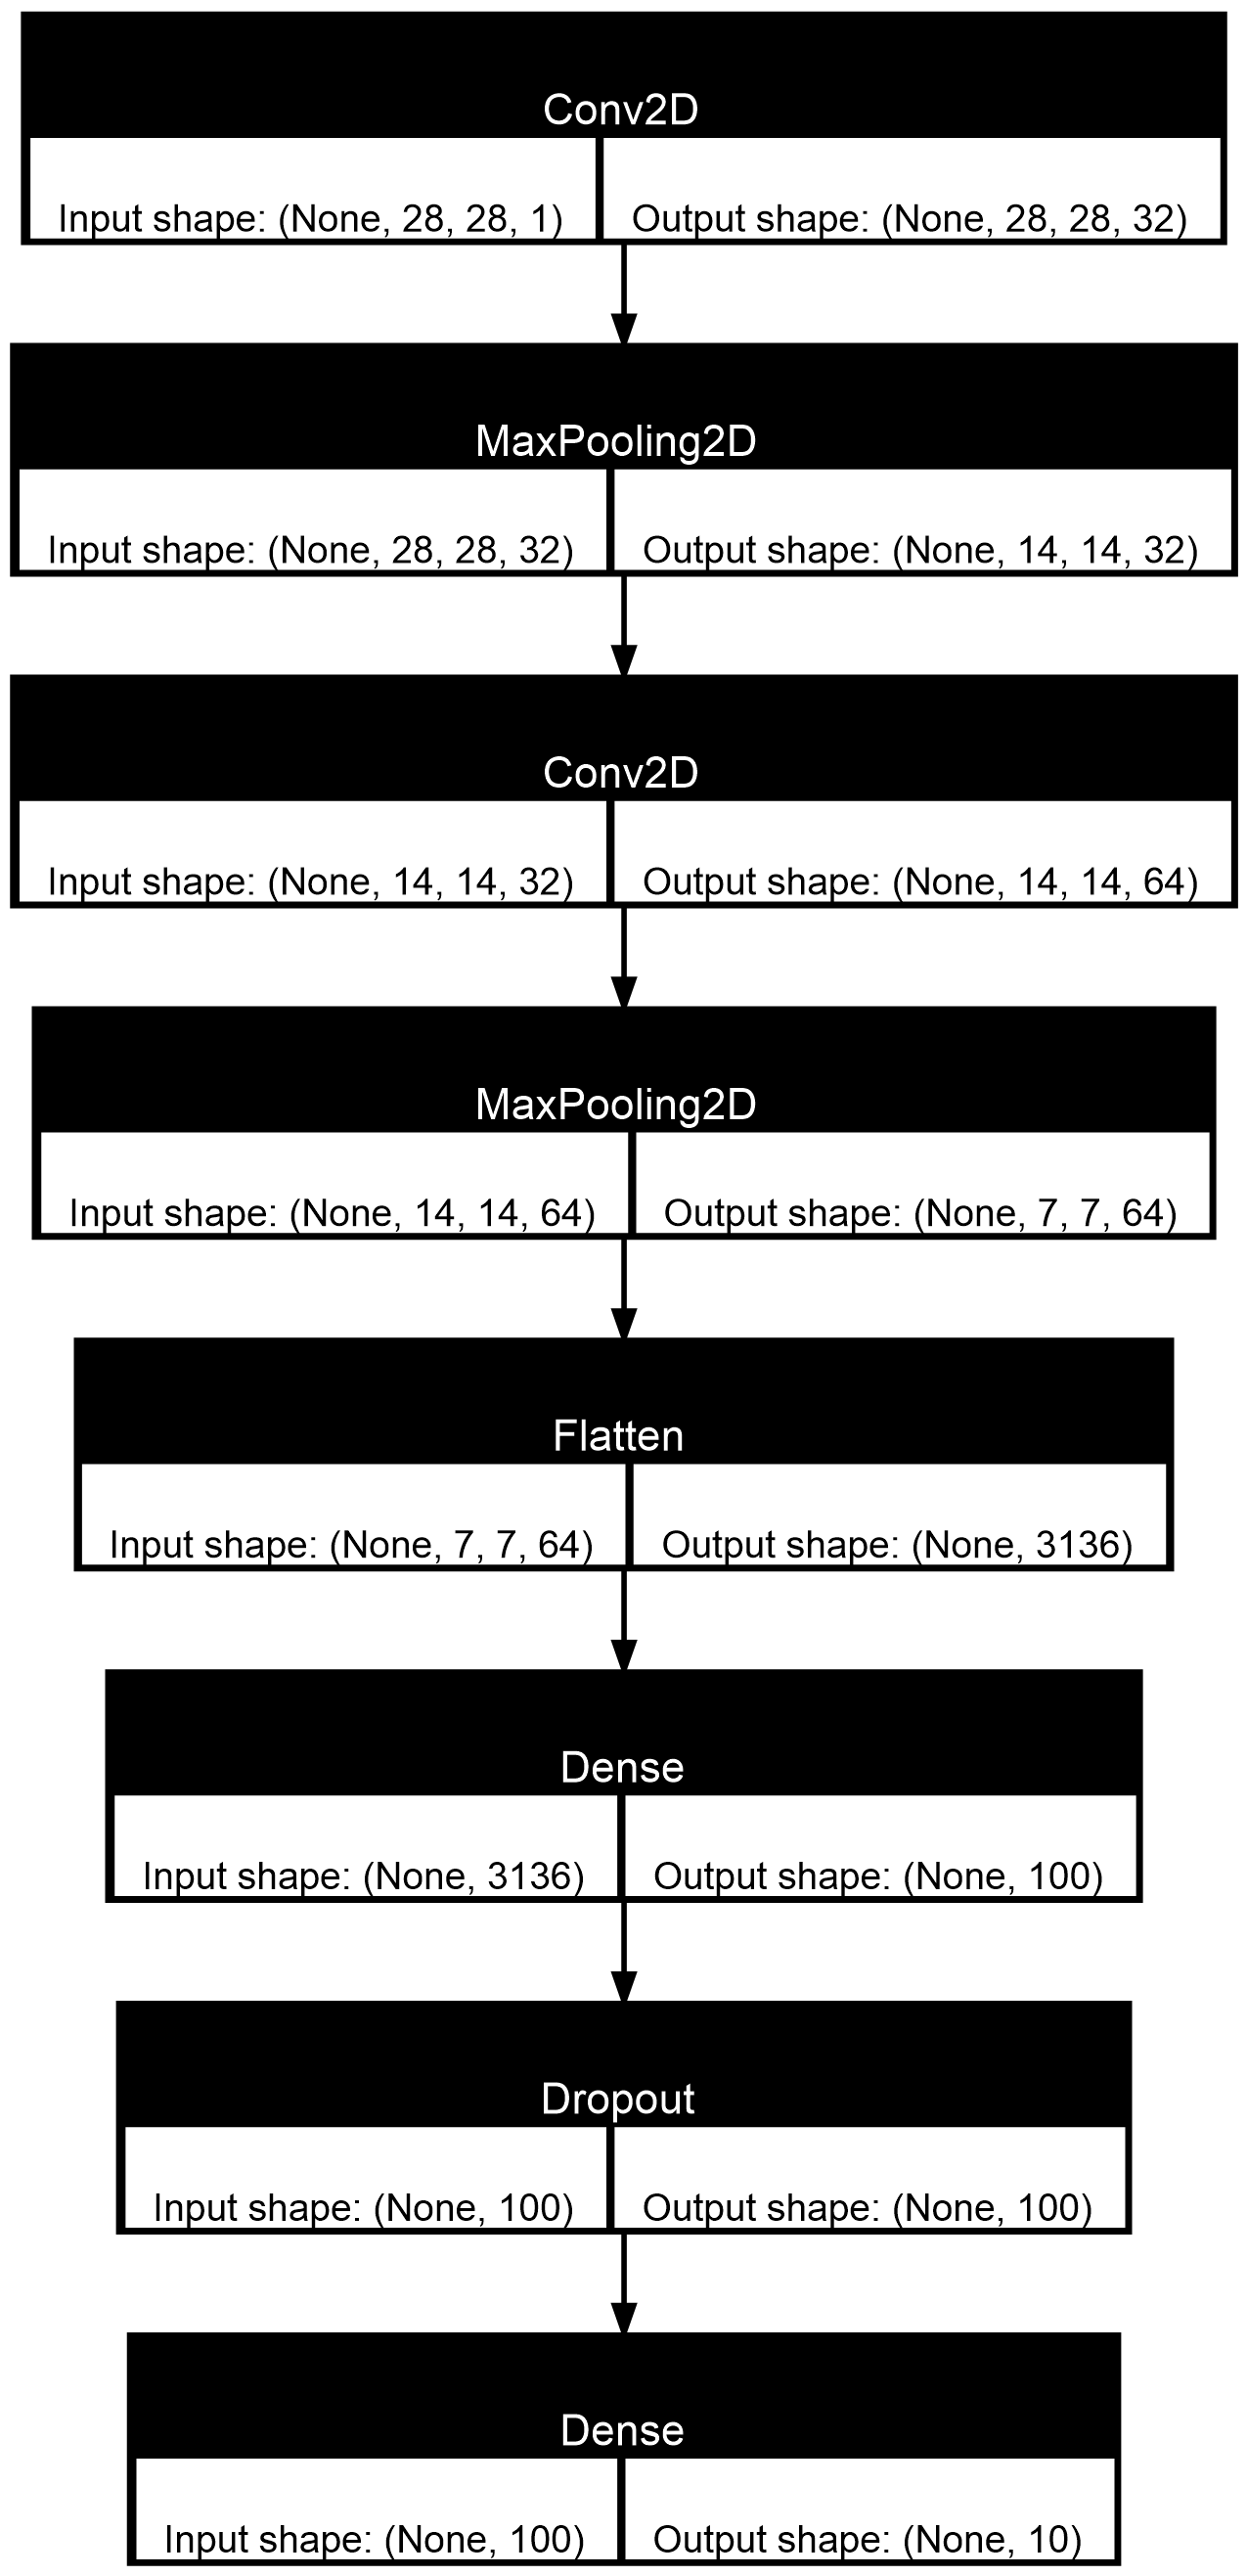

In [7]:
keras.utils.plot_model(model, show_shapes=True)

In [8]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target), callbacks=[checkpoint_cb, early_stopping_cb])
# 여기서 fit 한 결과를 history 라는 객체에 저장했어야 한다!

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.8084 - loss: 0.5334 - val_accuracy: 0.8759 - val_loss: 0.3312
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8732 - loss: 0.3535 - val_accuracy: 0.8960 - val_loss: 0.2803
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.8900 - loss: 0.3047 - val_accuracy: 0.9048 - val_loss: 0.2580
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9033 - loss: 0.2703 - val_accuracy: 0.9094 - val_loss: 0.2426
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9095 - loss: 0.2477 - val_accuracy: 0.9144 - val_loss: 0.2319
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9172 - loss: 0.2253 - val_accuracy: 0.9118 - val_loss: 0.2360
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9246 - loss: 0.2072 - val_accuracy: 0.9200 - val_loss: 0.2246
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9293 -

In [9]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9200 - loss: 0.2246


[0.22462457418441772, 0.9200000166893005]

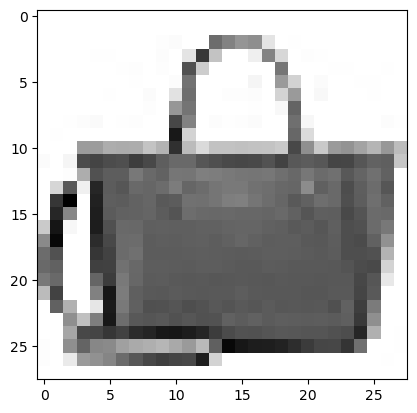

In [11]:
import matplotlib.pyplot as plt
plt.imshow(val_scaled[0].reshape(28, 28), cmap='grey_r')
plt.show()

In [12]:
preds = model.predict(val_scaled[0:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


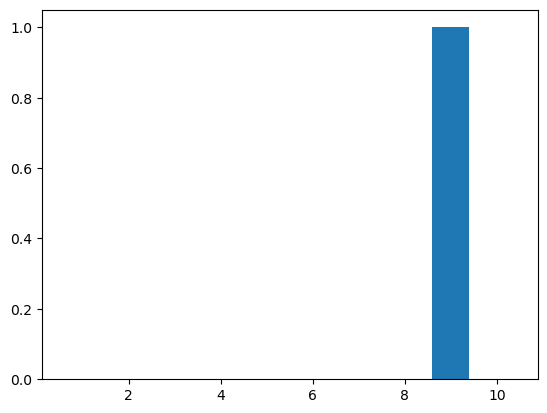

In [13]:
plt.bar(range(1, 11), preds[0])
plt.show()

In [14]:
model = keras.models.load_model('best-model.keras')

In [15]:
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [16]:
conv = model.layers[0]
print(conv.weights[0])

<Variable path=conv2d/kernel, shape=(3, 3, 1, 32), dtype=float32, value=[[[[ 1.90836012e-01 -2.90753487e-02  6.97453693e-02 -1.12480424e-01
    -1.18494332e+00 -6.19423650e-02 -5.79850823e-02 -6.95022494e-02
     1.77253902e-01 -2.02945113e-01  5.42564169e-02  1.29117757e-01
     2.28214204e-01  1.95624933e-01  3.44599932e-01 -2.01785251e-01
     2.75536656e-01 -5.14046848e-02 -5.86024784e-02  1.76588684e-01
    -6.40611947e-02 -3.58851582e-01  2.57194906e-01  1.92416519e-01
    -9.62866992e-02 -8.24600533e-02  2.65534725e-02 -6.44245297e-02
     1.83892280e-01  5.02562746e-02 -2.20029444e-01 -1.29107490e-01]]

  [[-1.01979181e-01 -1.64397359e-01  8.51788446e-02 -6.61962271e-01
    -1.43317723e+00  1.36324286e-01  6.96137175e-02  2.45335475e-01
     4.15987045e-01 -9.85485166e-02 -4.99585569e-02  2.53420006e-02
    -8.28057751e-02 -3.45174938e-01 -1.60125047e-01  9.02060717e-02
     3.77557017e-02 -2.13337809e-01  1.58122197e-01 -1.39327049e-01
     2.48155683e-01  1.47035271e-01 -2.13

In [17]:
conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std())

-0.011417154 0.22443943


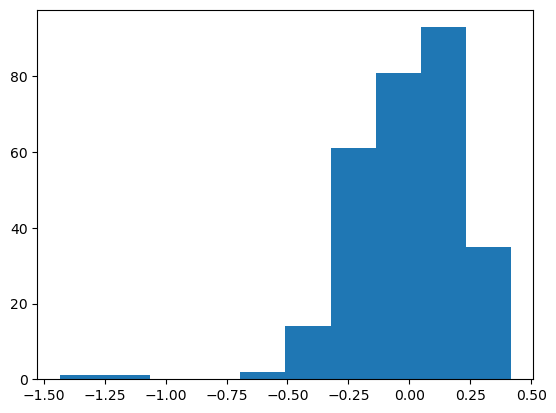

In [18]:
plt.hist(conv_weights.reshape(-1, 1))
plt.show()

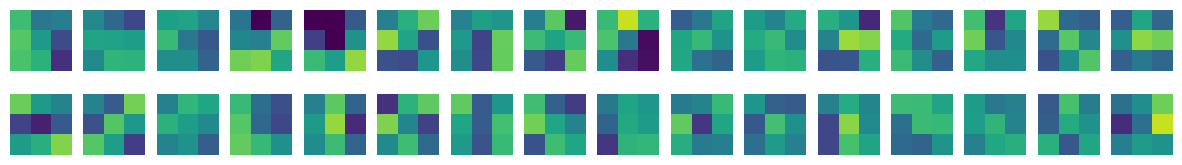

In [21]:
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show() 

In [22]:
conv_weights

array([[[[ 1.90836012e-01, -2.90753487e-02,  6.97453693e-02,
          -1.12480424e-01, -1.18494332e+00, -6.19423650e-02,
          -5.79850823e-02, -6.95022494e-02,  1.77253902e-01,
          -2.02945113e-01,  5.42564169e-02,  1.29117757e-01,
           2.28214204e-01,  1.95624933e-01,  3.44599932e-01,
          -2.01785251e-01,  2.75536656e-01, -5.14046848e-02,
          -5.86024784e-02,  1.76588684e-01, -6.40611947e-02,
          -3.58851582e-01,  2.57194906e-01,  1.92416519e-01,
          -9.62866992e-02, -8.24600533e-02,  2.65534725e-02,
          -6.44245297e-02,  1.83892280e-01,  5.02562746e-02,
          -2.20029444e-01, -1.29107490e-01]],

        [[-1.01979181e-01, -1.64397359e-01,  8.51788446e-02,
          -6.61962271e-01, -1.43317723e+00,  1.36324286e-01,
           6.96137175e-02,  2.45335475e-01,  4.15987045e-01,
          -9.85485166e-02, -4.99585569e-02,  2.53420006e-02,
          -8.28057751e-02, -3.45174938e-01, -1.60125047e-01,
           9.02060717e-02,  3.77557017

In [23]:
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Input(shape=(28,28,1)))
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))


In [32]:
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

(3, 3, 1, 32)


In [ ]:
no_training_conv = no_training_conv.weights[0].numpy()
print(no_training_conv.mean(), no_training_conv.std())

0.002544396 0.08025552


In [42]:
inputs = keras.layers.Input(shape=(784, ))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')


In [44]:
hidden = dense1(inputs)

In [45]:
outputs = dense2(hidden)

In [46]:
func_model = keras.Model(inputs, outputs)

In [47]:
func_model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
conv_acti = keras.Model(model.inputs[0], model.layers[0].output)

In [51]:
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0
feature_maps = conv_acti.predict(ankle_boot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


In [54]:
print(ankle_boot)

[[[[0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]]

  [[0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]]

  [[0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [0.        ]
   [

In [55]:
print(feature_maps.shape)

(1, 28, 28, 32)


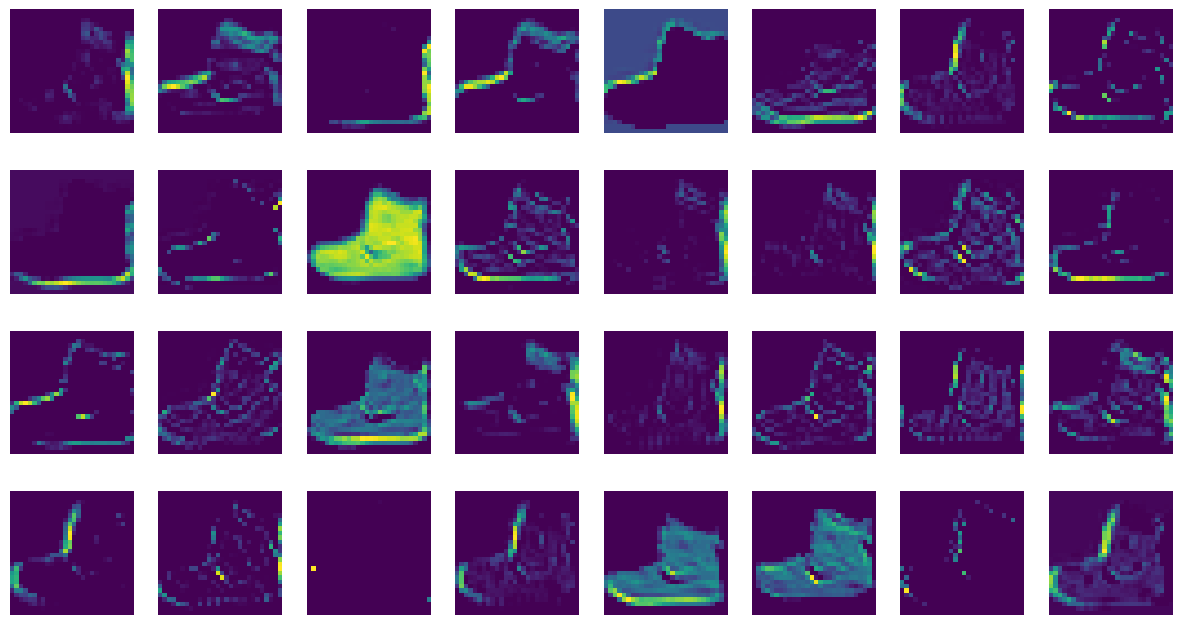

In [59]:
fig, axs = plt.subplots(4, 8, figsize=(15, 8))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0, :, :, i*8+j])
        axs[i, j].axis('off')


In [58]:
conv2_acti = keras.Model(model.inputs[0], model.layers[2].output)